# Modelado del Riego

## Crear dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

# Cargar CSV
df = pd.read_csv('/content/drive/MyDrive/tfg/ventanasLC.csv')

df['instante'] = pd.to_datetime(df['instante'])
df = df.sort_values('instante').reset_index(drop=True)
df = df.drop(["HS10", "HS20","HS40", "HS50","HS60","direccion"], axis=1)
print(df.shape)
df.head()

Mounted at /content/drive
(24615, 11)


,instante,HS30,TS30,TA,HA,litros_incremento,tmedia,hmedia,radiacion,viento,precipitacion
0,2020-03-01 00:00:00,0.766229,14.680000,19.932143,0.512743,0.0,17.97,55.42,0.0,8.54,0.0
1,2020-03-01 01:00:00,0.766086,14.700000,19.311429,0.546371,0.0,17.49,57.25,0.0,7.56,0.0
2,2020-03-01 02:00:00,0.766083,14.750000,18.862500,0.541420,0.0,16.70,57.12,0.0,6.03,0.0
3,2020-03-01 03:00:00,0.766000,14.758571,18.466429,0.538407,0.0,17.08,54.88,0.0,9.45,0.0
4,2020-03-01 04:00:00,0.765936,14.810000,18.450000,0.541125,0.0,16.79,56.51,0.0,7.16,0.0


In [ ]:
def construir_muestra(df, idx_inicio):
    fila_base = df.iloc[idx_inicio]

    muestra = {
        'instante'  : fila_base['instante'],
        'HS30'      : fila_base['HS30'],
        'tmedia'    : fila_base['tmedia'],
        'hmedia'    : fila_base['hmedia'],
        'viento'    : fila_base['viento'],
        'radiacion' : fila_base['radiacion'],
        'TS30'      : fila_base['TS30'],
    }

    litros_acumulados = 0.0
    hs30_anterior     = fila_base['HS30']
    hs30_futuro       = fila_base['HS30']
    freq              = pd.Timedelta(hours=1)

    for i in range(idx_inicio + 1, len(df)):
        fila_actual   = df.iloc[i]
        fila_anterior = df.iloc[i - 1]

        salto = fila_actual['instante'] - fila_anterior['instante']
        if salto > freq:
            break
        if fila_actual['litros_incremento'] == 0:
            break
        if fila_actual['precipitacion'] > 0:
            break
        if fila_actual['HS30'] <= hs30_anterior:
            break

        litros_acumulados += fila_actual['litros_incremento']
        hs30_anterior      = fila_actual['HS30']
        hs30_futuro        = fila_actual['HS30']

    muestra['litros_regados'] = litros_acumulados
    muestra['HS30_futuro']    = hs30_futuro

    muestra['_valida'] = (litros_acumulados > 0) and (hs30_futuro > fila_base['HS30'])

    return muestra


indices_base = df.index[df['litros_incremento'] == 0].tolist()
print(f"Instantes candidatos (litros_incremento == 0): {len(indices_base)}")

muestras = [construir_muestra(df, idx) for idx in indices_base]

df_muestras = pd.DataFrame(muestras)

df_muestras = df_muestras[df_muestras['_valida']].drop(columns='_valida').reset_index(drop=True)

print(f"Muestras con riego efectivo y HS30 creciente: {len(df_muestras)}")
df_muestras.head(10)

Instantes candidatos (litros_incremento == 0): 22874
Muestras con riego efectivo y HS30 creciente: 798


,instante,HS30,tmedia,hmedia,viento,radiacion,TS30,litros_regados,HS30_futuro
0,2020-03-02 08:00:00,0.755350,20.20,42.84,27.04,165.3,15.180000,14.727273,0.784792
1,2020-03-04 12:00:00,0.756682,22.49,48.23,12.72,773.0,15.250000,7.636364,0.776733
2,2020-03-05 08:00:00,0.772650,15.91,59.89,10.02,74.1,15.930000,2.181818,0.773343
3,2020-03-07 12:00:00,0.771086,15.65,38.68,8.19,512.8,14.930000,8.181818,0.787700
4,2020-03-11 12:00:00,0.767543,24.20,40.09,7.29,779.0,14.784286,8.727273,0.785950
5,2020-03-13 12:00:00,0.769500,16.11,75.40,7.39,375.2,15.370000,5.454545,0.789533
6,2020-03-26 14:00:00,0.770633,16.40,43.40,5.63,637.7,13.870000,0.818182,0.770764
7,2020-04-03 10:00:00,0.768221,15.42,68.75,3.66,662.4,14.295000,2.454545,0.769058
8,2020-04-07 09:00:00,0.764643,16.32,76.50,1.65,293.9,14.750000,7.909091,0.783114
9,2020-04-07 14:00:00,0.780133,19.03,56.70,6.40,758.0,14.920000,2.727273,0.783071


In [ ]:
output_path = '/content/drive/MyDrive/tfg/muestras_riego.csv'
df_muestras.to_csv(output_path, index=False)
print(f"Guardado en: {output_path}")

Guardado en: /content/drive/MyDrive/tfg/muestras_riego.csv


## Seleccion de variables

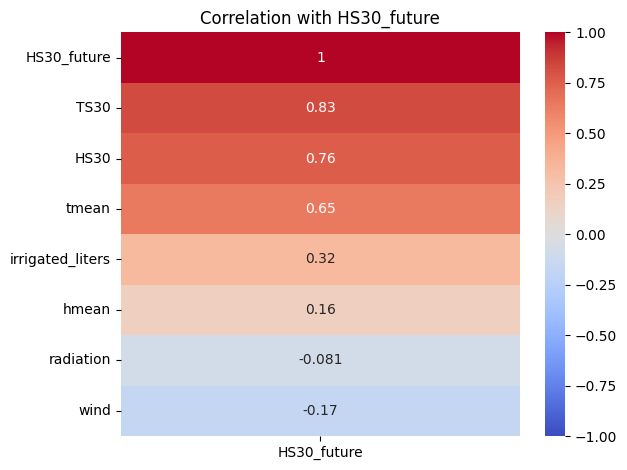

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

vars_candidatas = ['HS30', 'litros_regados', 'tmedia', 'hmedia',
                   'viento', 'radiacion', 'TS30']

label_map = {
    'HS30': 'HS30',
    'litros_regados': 'irrigated_liters',
    'tmedia': 'tmean',
    'hmedia': 'hmean',
    'viento': 'wind',
    'radiacion': 'radiation',
    'TA': 'TA',
    'HA': 'HA',
    'TS30': 'TS30',
    'HS30_futuro': 'HS30_future'
}

# Correlation
corr = df_muestras[vars_candidatas + ['HS30_futuro']].corr()

corr_target = corr[['HS30_futuro']].sort_values('HS30_futuro', ascending=False)

corr_target.index = [label_map[v] for v in corr_target.index]
corr_target.columns = ['HS30_future']


sns.heatmap(corr_target,
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1)

plt.title('Correlation with HS30_future')
plt.tight_layout()
plt.show()

tmedia            0.330370
TA                0.313389
litros_regados    0.304863
TS30              0.227493
radiacion         0.119358
viento            0.113640
HA               -0.103581
hmedia           -0.109058
HS30             -0.235156
Name: delta_HS30, dtype: float64


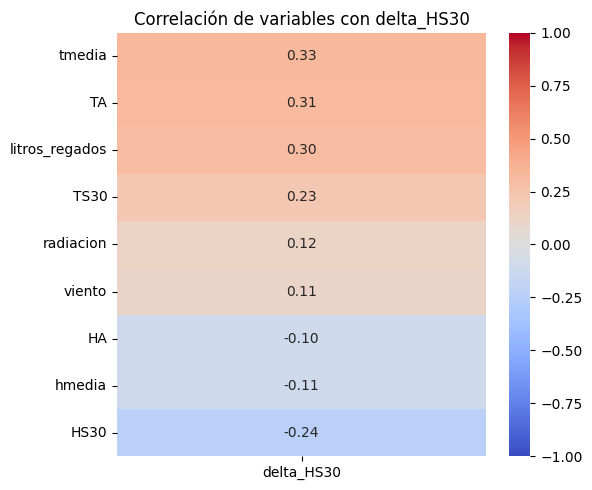

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_muestras['delta_HS30'] = df_muestras['HS30_futuro'] - df_muestras['HS30']

vars_candidatas = ['HS30', 'litros_regados', 'tmedia', 'hmedia',
                   'viento', 'radiacion', 'TA', 'HA', 'TS30']

corr_delta = (df_muestras[vars_candidatas + ['delta_HS30']]
              .corr()['delta_HS30']
              .drop('delta_HS30')
              .sort_values(ascending=False))

print(corr_delta)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_delta.to_frame(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de variables con delta_HS30')
plt.tight_layout()
plt.show()

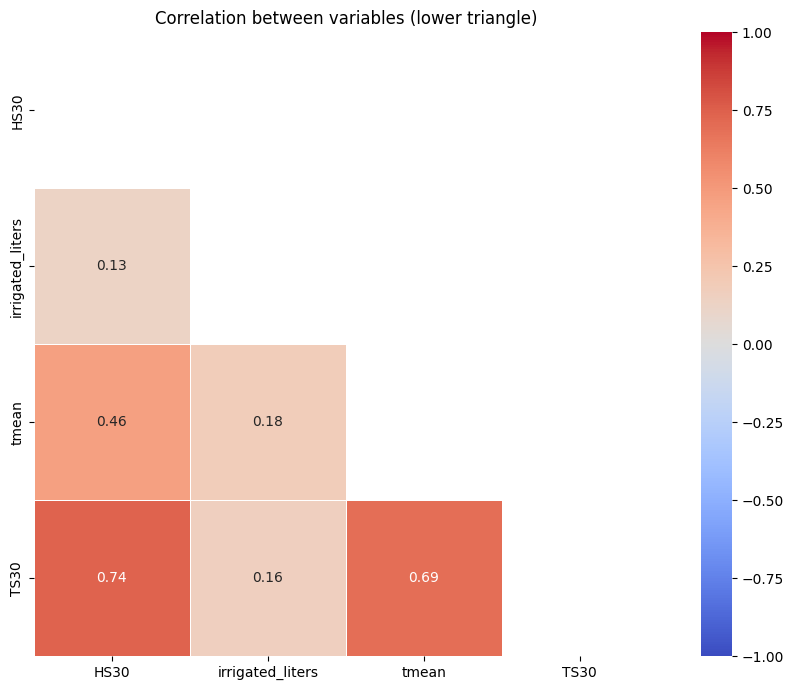


Pairs with |correlation| > 0.75:
----------------------------------------

Variance Inflation Factor (VIF):
        Variable      VIF
            TS30 3.287891
            HS30 2.203917
           tmean 1.932280
irrigated_liters 1.037172


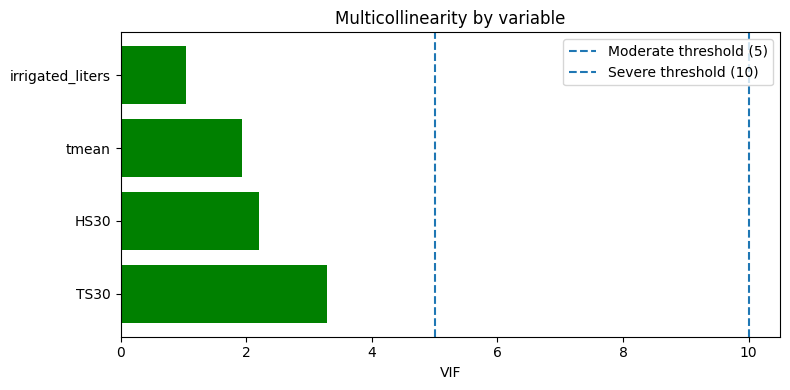

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd

vars_candidatas = ['HS30', 'litros_regados', 'tmedia', 'TS30']

label_map = {
    'HS30': 'HS30',
    'litros_regados': 'irrigated_liters',
    'tmedia': 'tmean',
    'hmedia': 'hmean',
    'viento': 'wind',
    'radiacion': 'radiation',
    'TA': 'TA',
    'HA': 'HA',
    'TS30': 'TS30'
}

plt.figure(figsize=(9, 7))

corr_matrix = df_muestras[vars_candidatas].corr()

corr_plot = corr_matrix.copy()
corr_plot.columns = [label_map[c] for c in corr_plot.columns]
corr_plot.index   = [label_map[c] for c in corr_plot.index]

mask = np.triu(np.ones_like(corr_plot, dtype=bool))

sns.heatmap(corr_plot, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, square=True)

plt.title('Correlation between variables (lower triangle)')
plt.tight_layout()
plt.show()

umbral = 0.75
print(f"\nPairs with |correlation| > {umbral}:")
print("-" * 40)

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > umbral:
            v1 = label_map[corr_matrix.columns[i]]
            v2 = label_map[corr_matrix.columns[j]]
            print(f"  {v1:20} – {v2:20}  r = {r:.2f}")

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(df_muestras[vars_candidatas]),
    columns=vars_candidatas
)

vif_data = pd.DataFrame({
    'Variable': vars_candidatas,
    'VIF': [variance_inflation_factor(X_scaled.values, i)
            for i in range(X_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

# translate names
vif_data['Variable'] = vif_data['Variable'].map(label_map)

print("\nVariance Inflation Factor (VIF):")
print(vif_data.to_string(index=False))

colors = ['red' if v > 10 else 'orange' if v > 5 else 'green'
          for v in vif_data['VIF']]

plt.figure(figsize=(8, 4))
plt.barh(vif_data['Variable'], vif_data['VIF'], color=colors)

plt.axvline(5,  linestyle='--', label='Moderate threshold (5)')
plt.axvline(10, linestyle='--', label='Severe threshold (10)')

plt.xlabel('VIF')
plt.title('Multicollinearity by variable')
plt.legend()

plt.tight_layout()
plt.show()

        Variable      VIF
            TS30 3.287891
            HS30 2.203917
           tmean 1.932280
irrigated_liters 1.037172


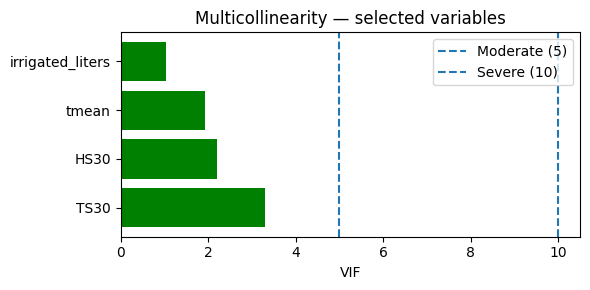

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

vars_modelo = ['HS30', 'tmedia', 'litros_regados','TS30']

label_map = {
    'HS30': 'HS30',
    'tmedia': 'tmean',
    'litros_regados': 'irrigated_liters',
    'TS30': 'TS30'
}

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(df_muestras[vars_modelo]),
    columns=vars_modelo
)

vif_data = pd.DataFrame({
    'Variable': vars_modelo,
    'VIF': [variance_inflation_factor(X_scaled.values, i)
            for i in range(X_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

# translate names
vif_data['Variable'] = vif_data['Variable'].map(label_map)

print(vif_data.to_string(index=False))

colors = ['red' if v > 10 else 'orange' if v > 5 else 'green'
          for v in vif_data['VIF']]

plt.figure(figsize=(6, 3))
plt.barh(vif_data['Variable'], vif_data['VIF'], color=colors)

plt.axvline(5, linestyle='--', label='Moderate (5)')
plt.axvline(10, linestyle='--', label='Severe (10)')

plt.xlabel('VIF')
plt.title('Multicollinearity — selected variables')
plt.legend()

plt.tight_layout()
plt.show()

## Modelo predictivo

Train: 678 | Test: 120

── CV en Train ───────────────────────────────────────
          Modelo    R2_cv   R2_std   MAE_cv  RMSE_cv
GradientBoosting 0.830287 0.015415 0.005449 0.007434
    RandomForest 0.794011 0.020913 0.006040 0.008195
           Ridge 0.781192 0.013914 0.006452 0.008447
LinearRegression 0.781145 0.013927 0.006452 0.008447

── Evaluación en Test ────────────────────────────────
          Modelo  R2_test  MAE_test  RMSE_test
GradientBoosting 0.764185  0.006277   0.009066
           Ridge 0.725897  0.007141   0.009774
LinearRegression 0.725740  0.007143   0.009777
    RandomForest 0.711182  0.006804   0.010033

── Resumen completo ──────────────────────────────────
          Modelo    R2_cv   R2_std  R2_test   Gap_R2  MAE_test  RMSE_test
GradientBoosting 0.830287 0.015415 0.764185 0.066102  0.006277   0.009066
    RandomForest 0.794011 0.020913 0.711182 0.082829  0.006804   0.010033
           Ridge 0.781192 0.013914 0.725897 0.055295  0.007141   0.009774
LinearRegress

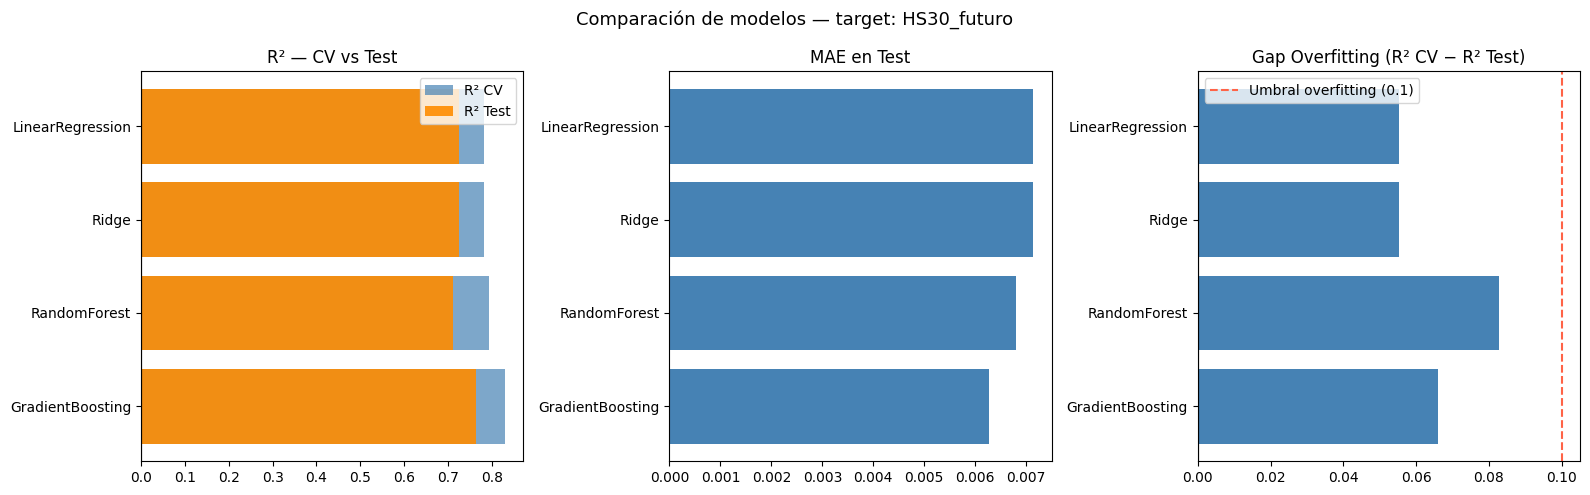

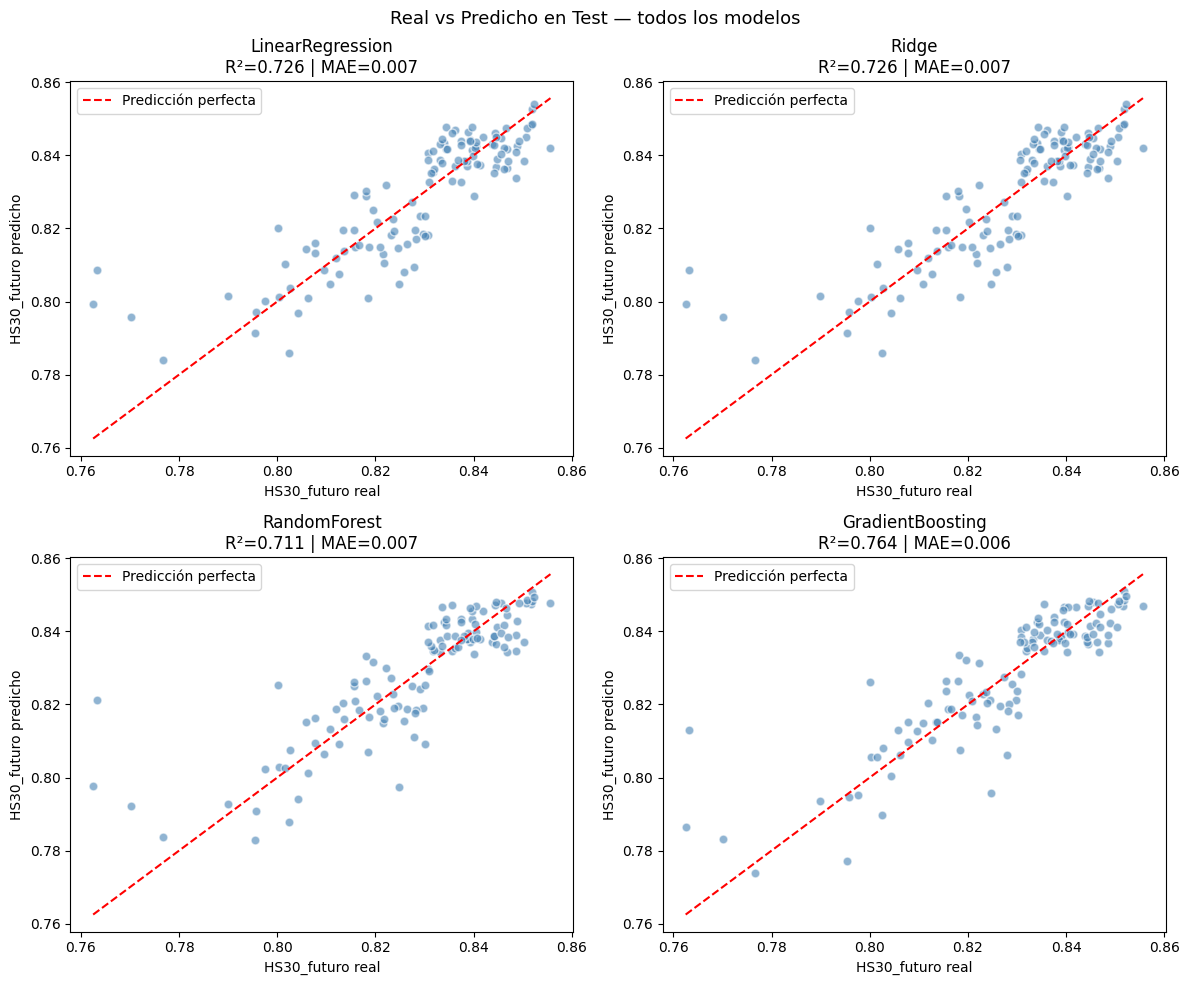

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vars_modelo = ['HS30', 'tmedia', 'litros_regados', 'TS30']
target      = 'HS30_futuro'

X = df_muestras[vars_modelo]
y = df_muestras[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

modelos = {
    'LinearRegression' : Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge'            : Pipeline([('scaler', StandardScaler()), ('model', Ridge())]),
    'RandomForest'     : RandomForestRegressor(n_estimators=200, max_depth=5,
                                               min_samples_leaf=10, random_state=42),
    'GradientBoosting' : GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                                   learning_rate=0.05, random_state=42),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
resultados    = []
modelos_fit   = {}

for nombre, modelo in modelos.items():
    r2_cv   = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='r2')
    mae_cv  = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    rmse_cv = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')

    modelo.fit(X_train, y_train)
    modelos_fit[nombre] = modelo

    resultados.append({
        'Modelo'  : nombre,
        'R2_cv'   : r2_cv.mean(),
        'R2_std'  : r2_cv.std(),
        'MAE_cv'  : (-mae_cv).mean(),
        'RMSE_cv' : (-rmse_cv).mean(),
    })

df_cv = pd.DataFrame(resultados).sort_values('R2_cv', ascending=False)
print("\n── CV en Train ───────────────────────────────────────")
print(df_cv.to_string(index=False))

resultados_test = []

for nombre, modelo in modelos_fit.items():
    y_pred = modelo.predict(X_test)
    resultados_test.append({
        'Modelo'  : nombre,
        'R2_test' : r2_score(y_test, y_pred),
        'MAE_test': mean_absolute_error(y_test, y_pred),
        'RMSE_test': mean_squared_error(y_test, y_pred) ** 0.5,
    })

df_test = pd.DataFrame(resultados_test).sort_values('R2_test', ascending=False)
print("\n── Evaluación en Test ────────────────────────────────")
print(df_test.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

x     = np.arange(len(df_resumen))
width = 0.35
axes[0].barh(df_resumen['Modelo'], df_resumen['R2_cv'],   alpha=0.7, label='R² CV',   color='steelblue')
axes[0].barh(df_resumen['Modelo'], df_resumen['R2_test'], alpha=0.9, label='R² Test',  color='darkorange')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('R² — CV vs Test')
axes[0].legend()

# MAE test
axes[1].barh(df_resumen['Modelo'], df_resumen['MAE_test'], color='steelblue')
axes[1].set_title('MAE en Test')

colors = ['tomato' if v > 0.1 else 'steelblue' for v in df_resumen['Gap_R2']]
axes[2].barh(df_resumen['Modelo'], df_resumen['Gap_R2'], color=colors)
axes[2].axvline(0.1, color='tomato',  linestyle='--', label='Umbral overfitting (0.1)')
axes[2].axvline(0,   color='black',   linewidth=0.8)
axes[2].set_title('Gap Overfitting (R² CV − R² Test)')
axes[2].legend()

plt.suptitle('Comparación de modelos — target: HS30_futuro', fontsize=13)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(modelos_fit.items()):
    y_pred = modelo.predict(X_test)
    r2     = r2_score(y_test, y_pred)
    mae    = mean_absolute_error(y_test, y_pred)

    axes[i].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=40)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[i].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
    axes[i].set_xlabel('HS30_futuro real')
    axes[i].set_ylabel('HS30_futuro predicho')
    axes[i].set_title(f'{nombre}\nR²={r2:.3f} | MAE={mae:.3f}')
    axes[i].legend()

plt.suptitle('Real vs Predicho en Test — todos los modelos', fontsize=13)
plt.tight_layout()
plt.show()

Train: 598 | Test: 200

  GridSearch — LightGBM
Fitting 5 folds for each of 1728 candidates, totalling 8640 fits

  ✔ Mejores hiperparámetros — LightGBM:
      colsample_bytree       : 1.0
      learning_rate          : 0.05
      max_depth              : 5
      min_child_samples      : 10
      n_estimators           : 100
      num_leaves             : 31
      reg_alpha              : 0
      reg_lambda             : 0.5
      subsample              : 0.8

  R² CV   : 0.8292
  R² Test : 0.7708
  MAE     : 0.0061
  RMSE    : 0.0088

  GridSearch — XGBoost
Fitting 5 folds for each of 864 candidates, totalling 4320 fits

  ✔ Mejores hiperparámetros — XGBoost:
      colsample_bytree       : 1.0
      learning_rate          : 0.05
      max_depth              : 5
      min_child_weight       : 5
      n_estimators           : 100
      reg_alpha              : 0
      reg_lambda             : 0.5
      subsample              : 0.8

  R² CV   : 0.8407
  R² Test : 0.7774
  MAE     : 0.006

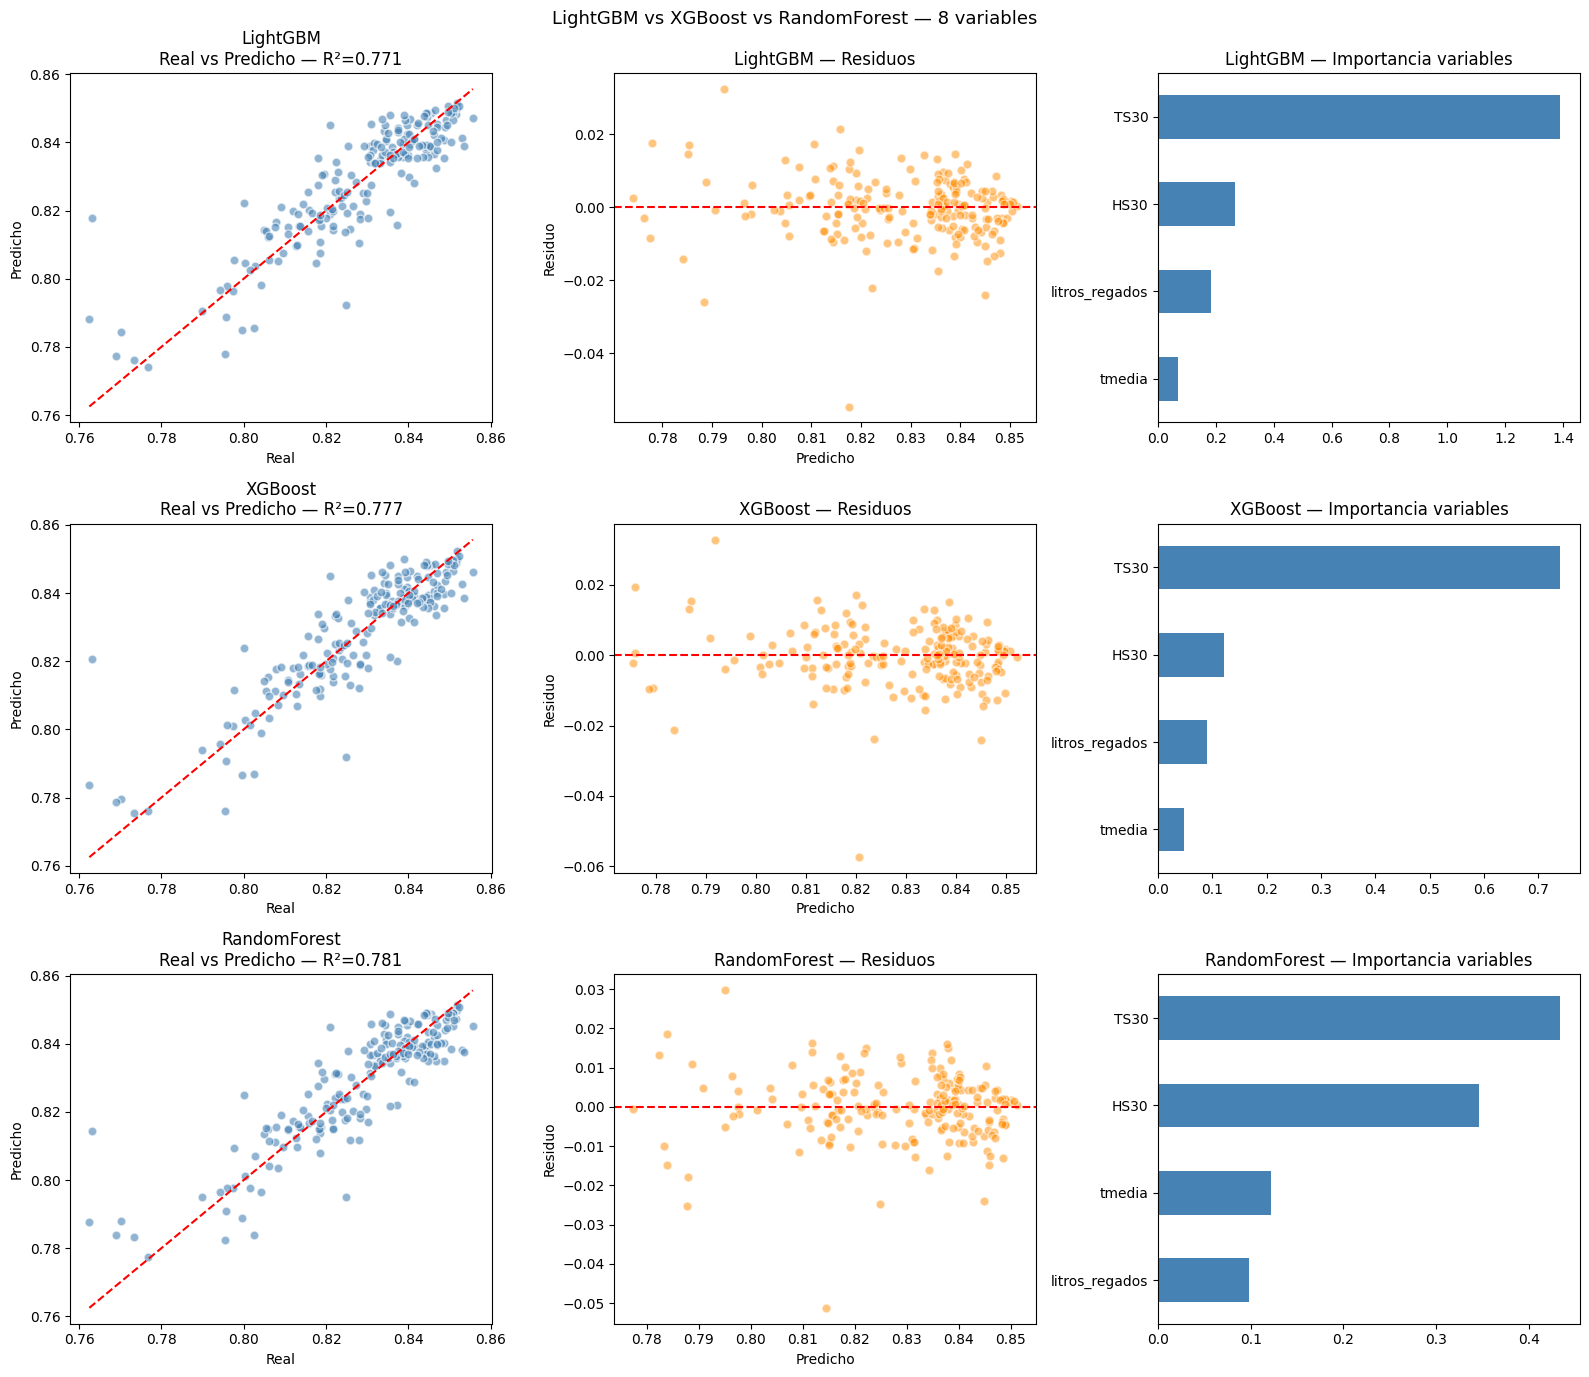

In [ ]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vars_modelo = ['HS30', 'litros_regados',
               'tmedia','TS30']
target      = 'HS30_futuro'

X = df_muestras[vars_modelo]
y = df_muestras[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── Grids de hiperparámetros ──────────────────────────────
params = {
    'LightGBM': (
        lgb.LGBMRegressor(random_state=42, verbose=-1),
        {
            'n_estimators'     : [100, 300, 500],
            'max_depth'        : [-1, 5, 7],
            'learning_rate'    : [0.05, 0.1, 0.2],
            'num_leaves'       : [31, 50],
            'min_child_samples': [10, 20],
            'subsample'        : [0.8, 1.0],
            'colsample_bytree' : [0.8, 1.0],
            'reg_alpha'        : [0, 0.1],
            'reg_lambda'       : [0, 0.5],
        }
    ),
    'XGBoost': (
        xgb.XGBRegressor(random_state=42, verbosity=0),
        {
            'n_estimators'    : [100, 300, 500],
            'max_depth'       : [3, 5, 7],
            'learning_rate'   : [0.05, 0.1, 0.2],
            'subsample'       : [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
            'reg_alpha'       : [0, 0.1],
            'reg_lambda'      : [0, 0.5],
            'min_child_weight': [1, 5],
        }
    ),
    'RandomForest': (
        RandomForestRegressor(random_state=42),
        {
            'n_estimators'    : [100, 200, 300],
            'max_depth'       : [None, 8, 10],
            'min_samples_leaf': [1, 5, 10],
            'max_features'    : ['sqrt', 0.5, 0.8],
            'max_samples'     : [0.8, 1.0],
        }
    ),
}

resultados  = {}
modelos_fit = {}

for nombre, (estimador, param_grid) in params.items():
    print(f"\n{'='*55}")
    print(f"  GridSearch — {nombre}")
    print(f"{'='*55}")

    search = GridSearchCV(
        estimator  = estimador,
        param_grid = param_grid,
        cv         = 5,
        scoring    = 'r2',
        n_jobs     = -1,
        verbose    = 1,
        refit      = True,
    )
    search.fit(X_train, y_train)

    y_pred = search.best_estimator_.predict(X_test)
    modelos_fit[nombre] = search.best_estimator_

    resultados[nombre] = {
        'r2_cv'  : search.best_score_,
        'r2_test': r2_score(y_test, y_pred),
        'mae'    : mean_absolute_error(y_test, y_pred),
        'rmse'   : mean_squared_error(y_test, y_pred) ** 0.5,
        'y_pred' : y_pred,
        'params' : search.best_params_,
    }

    print(f"\n  ✔ Mejores hiperparámetros — {nombre}:")
    for param, valor in search.best_params_.items():
        print(f"      {param:<22} : {valor}")
    print(f"\n  R² CV   : {search.best_score_:.4f}")
    print(f"  R² Test : {resultados[nombre]['r2_test']:.4f}")
    print(f"  MAE     : {resultados[nombre]['mae']:.4f}")
    print(f"  RMSE    : {resultados[nombre]['rmse']:.4f}")

print(f"\n{'='*55}")
print(f"  Comparativa final")
print(f"{'='*55}")
print(f"{'Modelo':<20} {'R² CV':>7} {'R² Test':>8} {'MAE':>8} {'RMSE':>8}")
print("-" * 55)
print(f"{'Anterior (4 vars)':<20} {'?':>7} {'0.7499':>8} {'0.0065':>8} {'0.0091':>8}")
for nombre, r in resultados.items():
    print(f"{nombre:<20} {r['r2_cv']:>7.4f} {r['r2_test']:>8.4f} {r['mae']:>8.4f} {r['rmse']:>8.4f}")

print(f"\n{'='*55}")
print("  Resumen mejores parámetros por modelo")
print(f"{'='*55}")
for nombre, r in resultados.items():
    print(f"\n  [{nombre}]")
    for param, valor in r['params'].items():
        print(f"    {param:<22} : {valor}")

# ── Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for row, (nombre, r) in enumerate(resultados.items()):

    axes[row, 0].scatter(y_test, r['y_pred'], alpha=0.6,
                         color='steelblue', edgecolors='white', s=40)
    lims = [min(y_test.min(), r['y_pred'].min()),
            max(y_test.max(), r['y_pred'].max())]
    axes[row, 0].plot(lims, lims, 'r--', linewidth=1.5)
    axes[row, 0].set_title(f"{nombre}\nReal vs Predicho — R²={r['r2_test']:.3f}")
    axes[row, 0].set_xlabel('Real')
    axes[row, 0].set_ylabel('Predicho')

    residuos = y_test.values - r['y_pred']
    axes[row, 1].scatter(r['y_pred'], residuos, alpha=0.5,
                         color='darkorange', edgecolors='white', s=40)
    axes[row, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[row, 1].set_title(f'{nombre} — Residuos')
    axes[row, 1].set_xlabel('Predicho')
    axes[row, 1].set_ylabel('Residuo')

    modelo = modelos_fit[nombre]
    if nombre == 'LightGBM':
        imp = pd.Series(modelo.booster_.feature_importance(importance_type='gain'),
                        index=vars_modelo)
    else:
        imp = pd.Series(modelo.feature_importances_, index=vars_modelo)

    imp.sort_values().plot(kind='barh', ax=axes[row, 2], color='steelblue')
    axes[row, 2].set_title(f'{nombre} — Importancia variables')

plt.suptitle('LightGBM vs XGBoost vs RandomForest — 8 variables', fontsize=13)
plt.tight_layout()
plt.show()

Augmentation

Train original : 558
Train aumentado: 1116


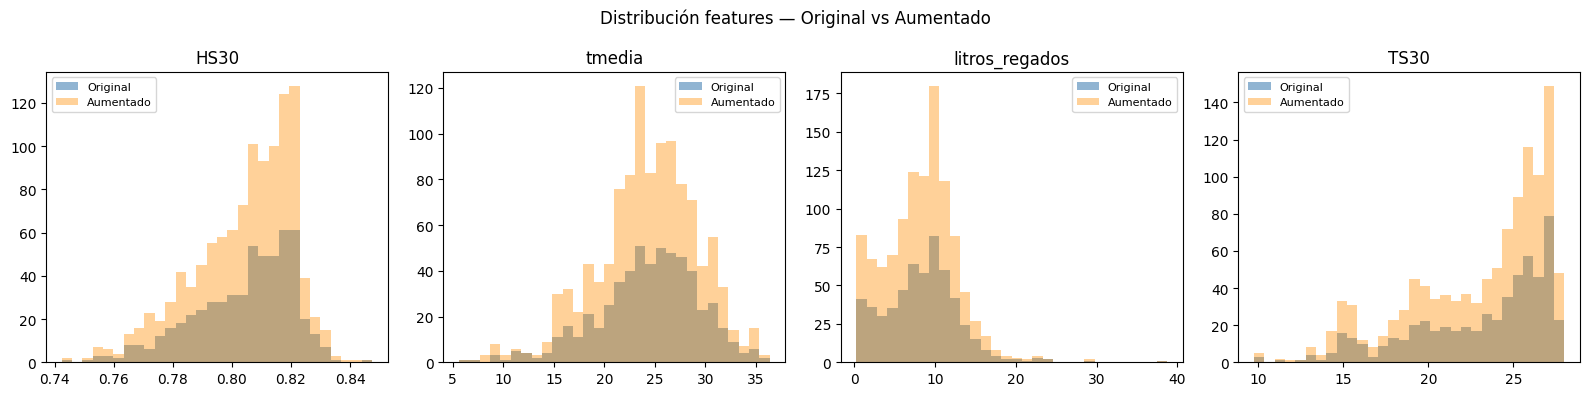

Fitting 5 folds for each of 60 candidates, totalling 300 fits

── Val (aumentado) ──────────────────────────────────
R²   : 0.7974
MAE  : 0.0059

── Test (aumentado) ─────────────────────────────────
R²   : 0.6605
MAE  : 0.0067
RMSE : 0.0106

── Comparativa ──────────────────────────────────────
                            R² Val  R² Test   MAE Test
-------------------------------------------------------
Sin augmentation            0.8138   0.7499     0.0065
Con augmentation            0.7974   0.6605     0.0067


In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

vars_modelo = ['HS30', 'tmedia', 'litros_regados', 'TS30']
target      = 'HS30_futuro'

X_train_df = X_train.copy()
y_train_s  = y_train.copy()

def augment_interpolation(X, y, n_samples, k=3):
    """
    Para cada muestra sintética:
      1. Elige una muestra base aleatoria
      2. Encuentra sus k vecinos más cercanos
      3. Interpola linealmente entre la base y un vecino aleatorio
    """
    from sklearn.preprocessing import StandardScaler

    scaler  = StandardScaler()
    X_sc    = scaler.fit_transform(X)
    knn     = NearestNeighbors(n_neighbors=k+1).fit(X_sc)
    _, idxs = knn.kneighbors(X_sc)

    X_arr   = X.values
    y_arr   = y.values
    X_new, y_new = [], []

    for _ in range(n_samples):
        i       = np.random.randint(0, len(X_arr))
        vecinos = idxs[i][1:]                          # excluir el propio
        j       = np.random.choice(vecinos)
        alpha   = np.random.uniform(0, 1)

        X_new.append(X_arr[i] + alpha * (X_arr[j] - X_arr[i]))
        y_new.append(y_arr[i] + alpha * (y_arr[j] - y_arr[i]))

    X_new = pd.DataFrame(X_new, columns=X.columns)
    y_new = pd.Series(y_new, name=y.name)

    return X_new, y_new

n_aug = len(X_train_df)   # duplicar el train

X_aug_b, y_aug_b = augment_interpolation(X_train_df, y_train_s, n_samples=n_aug)

X_train_aug = pd.concat([X_train_df, X_aug_b], ignore_index=True)
y_train_aug = pd.concat([y_train_s,  y_aug_b], ignore_index=True)

print(f"Train original : {len(X_train_df)}")
print(f"Train aumentado: {len(X_train_aug)}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(vars_modelo):
    axes[i].hist(X_train_df[col],  bins=30, alpha=0.6, label='Original',  color='steelblue')
    axes[i].hist(X_train_aug[col], bins=30, alpha=0.4, label='Aumentado', color='darkorange')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución features — Original vs Aumentado', fontsize=12)
plt.tight_layout()
plt.show()

from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

lgbm_params = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [-1, 3, 5, 7],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'num_leaves'       : [15, 31, 50],
    'min_child_samples': [5, 10, 20, 30],
    'subsample'        : [0.7, 0.8, 1.0],
    'colsample_bytree' : [0.7, 0.8, 1.0],
    'reg_alpha'        : [0, 0.1, 0.5],
    'reg_lambda'       : [0, 0.1, 0.5, 1.0],
}

search_aug = RandomizedSearchCV(
    estimator           = lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_distributions = lgbm_params,
    n_iter              = 60,
    cv                  = 5,
    scoring             = 'r2',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1,
    refit               = True,
)

search_aug.fit(X_train_aug, y_train_aug)

y_pred_val_aug = search_aug.best_estimator_.predict(X_val)
print(f"\n── Val (aumentado) ──────────────────────────────────")
print(f"R²   : {r2_score(y_val, y_pred_val_aug):.4f}")
print(f"MAE  : {mean_absolute_error(y_val, y_pred_val_aug):.4f}")

X_tv_aug = pd.concat([X_train_aug, X_val])
y_tv_aug = pd.concat([y_train_aug, y_val])

modelo_aug = lgb.LGBMRegressor(**search_aug.best_params_, random_state=42, verbose=-1)
modelo_aug.fit(X_tv_aug, y_tv_aug)

y_pred_test_aug = modelo_aug.predict(X_test)

print(f"\n── Test (aumentado) ─────────────────────────────────")
print(f"R²   : {r2_score(y_test, y_pred_test_aug):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_test_aug):.4f}")
print(f"RMSE : {mean_squared_error(y_test, y_pred_test_aug)**0.5:.4f}")

print(f"\n── Comparativa ──────────────────────────────────────")
print(f"{'':25} {'R² Val':>8} {'R² Test':>8} {'MAE Test':>10}")
print("-" * 55)
print(f"{'Sin augmentation':<25} {r2_score(y_val, y_pred_val):>8.4f} {r2_score(y_test, y_pred_test):>8.4f} {mean_absolute_error(y_test, y_pred_test):>10.4f}")
print(f"{'Con augmentation':<25} {r2_score(y_val, y_pred_val_aug):>8.4f} {r2_score(y_test, y_pred_test_aug):>8.4f} {mean_absolute_error(y_test, y_pred_test_aug):>10.4f}")

## Estadisticas atmosféricas

In [ ]:
def construir_muestra(df, idx_inicio):
    fila_base = df.iloc[idx_inicio]

    muestra = {
        'instante'  : fila_base['instante'],
        'HS30'      : fila_base['HS30'],
        'tmedia'    : fila_base['tmedia'],
        'hmedia'    : fila_base['hmedia'],
        'viento'    : fila_base['viento'],
        'radiacion' : fila_base['radiacion'],
        'TS30'      : fila_base['TS30']
    }

    litros_acumulados = 0.0
    hs30_anterior     = fila_base['HS30']
    hs30_futuro       = fila_base['HS30']
    freq              = pd.Timedelta(hours=1)

    filas_riego = []

    for i in range(idx_inicio + 1, len(df)):
        fila_actual   = df.iloc[i]
        fila_anterior = df.iloc[i - 1]

        salto = fila_actual['instante'] - fila_anterior['instante']
        if salto > freq:
            break
        if fila_actual['litros_incremento'] == 0:
            break
        if fila_actual['precipitacion'] > 0:
            break
        if fila_actual['HS30'] <= hs30_anterior:
            break

        litros_acumulados += fila_actual['litros_incremento']
        hs30_anterior      = fila_actual['HS30']
        hs30_futuro        = fila_actual['HS30']
        filas_riego.append(fila_actual)

    muestra['litros_regados'] = litros_acumulados
    muestra['HS30_futuro']    = hs30_futuro

    if filas_riego:
        df_riego = pd.DataFrame(filas_riego)

        for var in ['tmedia', 'hmedia', 'viento', 'radiacion']:
            muestra[f'{var}_riego_min']  = df_riego[var].min()
            muestra[f'{var}_riego_max']  = df_riego[var].max()
            muestra[f'{var}_riego_mean'] = df_riego[var].mean()
            muestra[f'{var}_riego_std']  = df_riego[var].std(ddof=0)  # ddof=0 por si hay 1 sola fila
    else:
        # Sin filas de riego → rellenar con NaN
        for var in ['tmedia', 'hmedia', 'viento', 'radiacion']:
            for stat in ['min', 'max', 'mean', 'std']:
                muestra[f'{var}_riego_{stat}'] = np.nan

    muestra['_valida'] = (litros_acumulados > 0) and (hs30_futuro > fila_base['HS30'])

    return muestra

indices_base = df.index[df['litros_incremento'] == 0].tolist()
print(f"Instantes candidatos: {len(indices_base)}")

muestras     = [construir_muestra(df, idx) for idx in indices_base]
df_muestras  = pd.DataFrame(muestras)
df_muestras  = df_muestras[df_muestras['_valida']].drop(columns='_valida').reset_index(drop=True)

print(f"Muestras válidas: {len(df_muestras)}")
print(f"Variables totales: {len(df_muestras.columns)}")
df_muestras.head()

Instantes candidatos: 22874
Muestras válidas: 798
Variables totales: 25


,instante,HS30,tmedia,hmedia,viento,radiacion,TS30,litros_regados,HS30_futuro,tmedia_riego_min,...,hmedia_riego_mean,hmedia_riego_std,viento_riego_min,viento_riego_max,viento_riego_mean,viento_riego_std,radiacion_riego_min,radiacion_riego_max,radiacion_riego_mean,radiacion_riego_std
0,2020-03-02 08:00:00,0.755350,20.20,42.84,27.04,165.3,15.180000,14.727273,0.784792,20.92,...,42.155,1.225,26.21,29.48,27.845,1.635,426.1,593.1,509.60,83.50
1,2020-03-04 12:00:00,0.756682,22.49,48.23,12.72,773.0,15.250000,7.636364,0.776733,23.12,...,42.830,1.450,15.03,15.99,15.510,0.480,672.6,696.0,684.30,11.70
2,2020-03-05 08:00:00,0.772650,15.91,59.89,10.02,74.1,15.930000,2.181818,0.773343,17.85,...,55.760,0.000,10.11,10.11,10.110,0.000,349.7,349.7,349.70,0.00
3,2020-03-07 12:00:00,0.771086,15.65,38.68,8.19,512.8,14.930000,8.181818,0.787700,18.05,...,34.945,0.885,5.48,8.51,6.995,1.515,694.3,752.0,723.15,28.85
4,2020-03-11 12:00:00,0.767543,24.20,40.09,7.29,779.0,14.784286,8.727273,0.785950,23.11,...,37.790,0.700,9.09,10.13,9.610,0.520,730.0,796.0,763.00,33.00


In [ ]:
output_path = '/content/drive/MyDrive/tfg/muestras_riego_atmosfericas.csv'
df_muestras.to_csv(output_path, index=False)
print(f"Guardado en: {output_path}")

Guardado en: /content/drive/MyDrive/tfg/muestras_riego_atmosfericas.csv


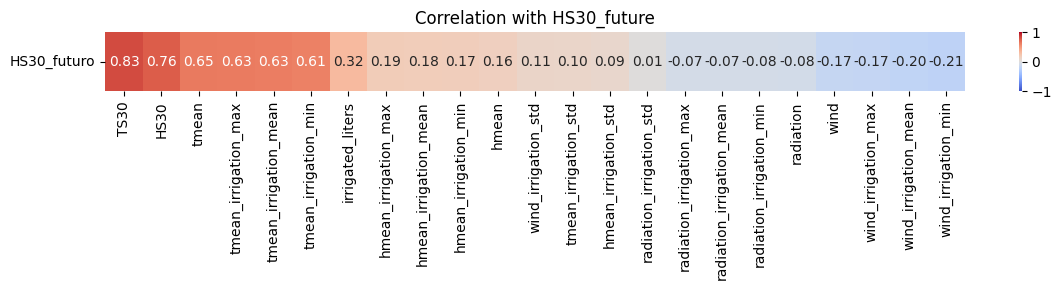

Variables with |correlation| > 0.2 with HS30_future:
TS30                     0.828105
HS30                     0.761655
tmean                    0.645286
tmean_irrigation_max     0.633848
tmean_irrigation_mean    0.625072
tmean_irrigation_min     0.612488
irrigated_liters         0.318460
wind_irrigation_min     -0.213995


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables del instante inicial
vars_iniciales = ['HS30','TS30', 'litros_regados',
                  'tmedia', 'hmedia', 'viento', 'radiacion']

# Estadísticos durante el riego
vars_riego = [f'{var}_riego_{stat}'
              for var in ['tmedia', 'hmedia', 'viento', 'radiacion']
              for stat in ['min', 'max', 'mean', 'std']]

vars_candidatas = vars_iniciales + vars_riego

label_map = {
    'HS30': 'HS30',
    'TS30': 'TS30',
    'litros_regados': 'irrigated_liters',
    'tmedia': 'tmean',
    'hmedia': 'hmean',
    'viento': 'wind',
    'radiacion': 'radiation'
}

def translate_var(v):
    for key in label_map:
        if v.startswith(key):
            return v.replace(key, label_map[key]).replace('_riego_', '_irrigation_')
    return v

corr = (df_muestras[vars_candidatas + ['HS30_futuro']]
        .corr()['HS30_futuro']
        .drop('HS30_futuro')
        .sort_values(ascending=False))

corr.index = [translate_var(v) for v in corr.index]

plt.figure(figsize=(12, 3))

sns.heatmap(corr.to_frame().T,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1,
            cbar=True)

plt.yticks(rotation=0)
plt.title('Correlation with HS30_future')
plt.tight_layout()
plt.show()

print("Variables with |correlation| > 0.2 with HS30_future:")
print(corr[abs(corr) > 0.2].to_string())

           Variable      VIF
               TS30 4.171714
              tmean 3.151602
               HS30 2.229889
wind_irrigation_min 1.765391
   irrigated_liters 1.039964


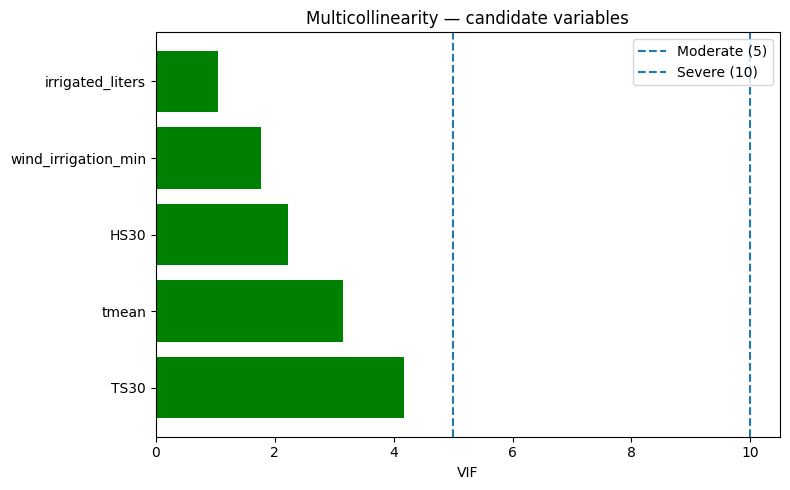

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

vars_modelo = ['HS30','TS30', 'tmedia', 'litros_regados',
               'viento_riego_min']

label_map = {
    'HS30': 'HS30',
    'TS30': 'TS30',
    'tmedia': 'tmean',
    'litros_regados': 'irrigated_liters',
    'viento': 'wind'
}

def translate_var(v):
    for key in label_map:
        if v.startswith(key):
            v = v.replace(key, label_map[key])
    v = v.replace('_riego_', '_irrigation_')
    return v

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(df_muestras[vars_modelo]),
    columns=vars_modelo
)

vif_data = pd.DataFrame({
    'Variable': vars_modelo,
    'VIF': [variance_inflation_factor(X_scaled.values, i)
            for i in range(X_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

vif_data['Variable'] = vif_data['Variable'].apply(translate_var)

print(vif_data.to_string(index=False))

colors = ['red' if v > 10 else 'orange' if v > 5 else 'green'
          for v in vif_data['VIF']]

plt.figure(figsize=(8, 5))
plt.barh(vif_data['Variable'], vif_data['VIF'], color=colors)

plt.axvline(5, linestyle='--', label='Moderate (5)')
plt.axvline(10, linestyle='--', label='Severe (10)')

plt.xlabel('VIF')
plt.title('Multicollinearity — candidate variables')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vars_modelo = ['HS30', 'litros_regados',
               'viento_riego_std', 'tmedia_riego_std',
               'radiacion_riego_std', 'viento_riego_min', 'TS30', 'tmedia']
target      = 'HS30_futuro'

X = df_muestras[vars_modelo]
y = df_muestras[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

lgbm_params = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [-1, 3, 5, 7],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'num_leaves'       : [15, 31, 50],
    'min_child_samples': [5, 10, 20, 30],
    'subsample'        : [0.7, 0.8, 1.0],
    'colsample_bytree' : [0.7, 0.8, 1.0],
    'reg_alpha'        : [0, 0.1, 0.5],
    'reg_lambda'       : [0, 0.1, 0.5, 1.0],
}

search = RandomizedSearchCV(
    estimator           = lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_distributions = lgbm_params,
    n_iter              = 60,
    cv                  = 5,
    scoring             = 'r2',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1,
    refit               = True,
)

search.fit(X_train, y_train)

print(f"\nMejores params : {search.best_params_}")
print(f"R² CV train    : {search.best_score_:.4f}")

y_pred_test = search.best_estimator_.predict(X_test)

print(f"\n── Test ─────────────────────────────────────────────")
print(f"R²   : {r2_score(y_test, y_pred_test):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE : {mean_squared_error(y_test, y_pred_test)**0.5:.4f}")

print(f"\n── Comparativa ──────────────────────────────────────")
print(f"{'':30} {'R² Test':>8} {'MAE':>8} {'RMSE':>8}")
print("-" * 58)
print(f"{'Modelo anterior (4 vars)':<30}  {'0.7499':>8} {'0.0065':>8} {'0.0091':>8}")
print(f"{'Nuevo (9 vars atm)':<30}  {r2_score(y_test, y_pred_test):>8.4f} {mean_absolute_error(y_test, y_pred_test):>8.4f} {mean_squared_error(y_test, y_pred_test):>8.4f}")

Train: 598 | Test: 200
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Mejores params : {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
R² CV train    : 0.8522

── Test ─────────────────────────────────────────────
R²   : 0.7954
MAE  : 0.0059
RMSE : 0.0083

── Comparativa ──────────────────────────────────────
                                R² Test      MAE     RMSE
----------------------------------------------------------
Modelo anterior (4 vars)          0.7499   0.0065   0.0091
Nuevo (9 vars atm)                0.7954   0.0059   0.0001


Train: 598 | Test: 200

  GridSearch — LightGBM
Fitting 5 folds for each of 1728 candidates, totalling 8640 fits

  ✔ Mejores hiperparámetros — LightGBM:
      colsample_bytree       : 0.8
      learning_rate          : 0.1
      max_depth              : 5
      min_child_samples      : 10
      n_estimators           : 100
      num_leaves             : 31
      reg_alpha              : 0
      reg_lambda             : 0.5
      subsample              : 0.8

  R² CV   : 0.8564
  R² Test : 0.8141
  MAE     : 0.0055
  RMSE    : 0.0079

  GridSearch — XGBoost
Fitting 5 folds for each of 864 candidates, totalling 4320 fits

  ✔ Mejores hiperparámetros — XGBoost:
      colsample_bytree       : 1.0
      learning_rate          : 0.05
      max_depth              : 5
      min_child_weight       : 5
      n_estimators           : 100
      reg_alpha              : 0
      reg_lambda             : 0.5
      subsample              : 0.8

  R² CV   : 0.8630
  R² Test : 0.8144
  MAE     : 0.0055

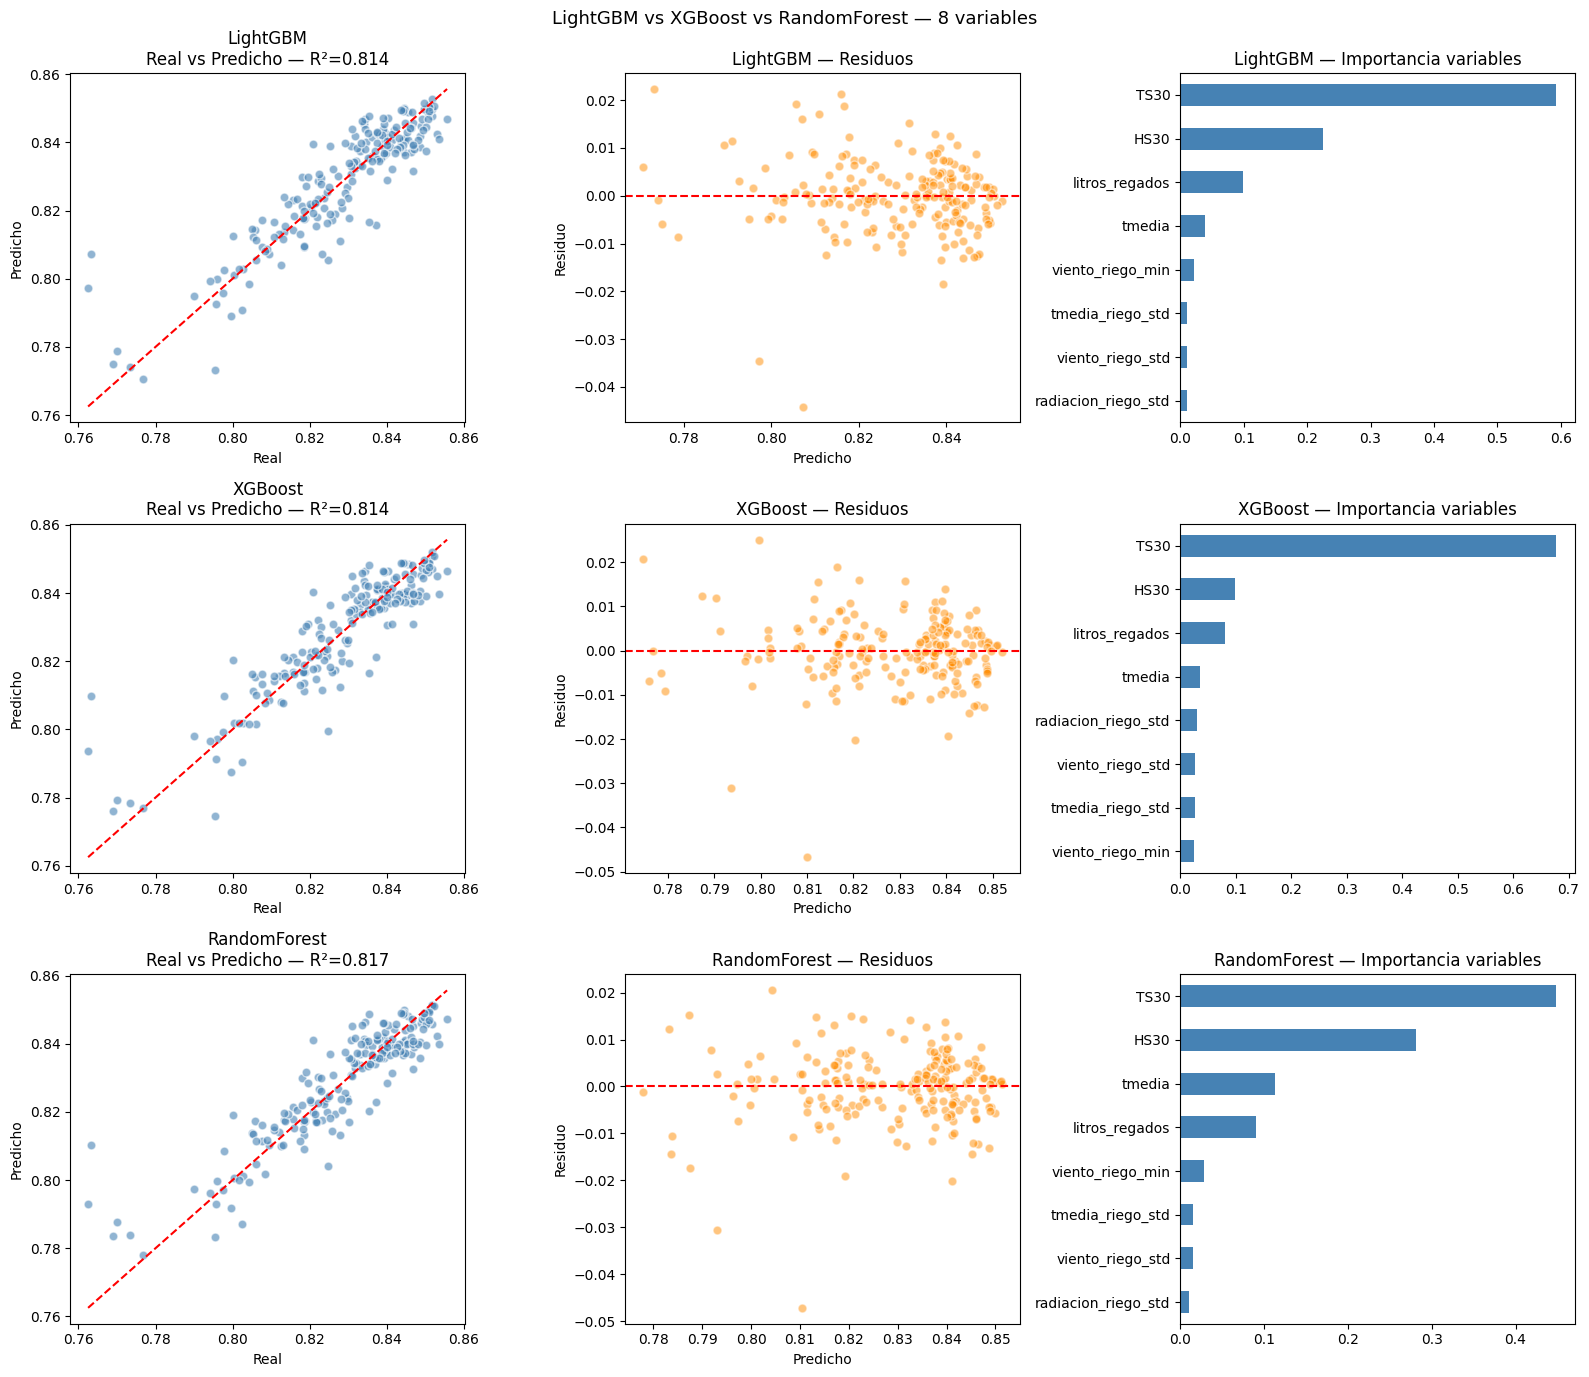

In [ ]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vars_modelo = ['HS30', 'litros_regados',
               'viento_riego_std', 'tmedia_riego_std', 'radiacion_riego_std',
               'tmedia','viento_riego_min', 'TS30']
target      = 'HS30_futuro'

X = df_muestras[vars_modelo]
y = df_muestras[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

params = {
    'LightGBM': (
        lgb.LGBMRegressor(random_state=42, verbose=-1),
        {
            'n_estimators'     : [100, 300, 500],
            'max_depth'        : [-1, 5, 7],
            'learning_rate'    : [0.05, 0.1, 0.2],
            'num_leaves'       : [31, 50],
            'min_child_samples': [10, 20],
            'subsample'        : [0.8, 1.0],
            'colsample_bytree' : [0.8, 1.0],
            'reg_alpha'        : [0, 0.1],
            'reg_lambda'       : [0, 0.5],
        }
    ),
    'XGBoost': (
        xgb.XGBRegressor(random_state=42, verbosity=0),
        {
            'n_estimators'    : [100, 300, 500],
            'max_depth'       : [3, 5, 7],
            'learning_rate'   : [0.05, 0.1, 0.2],
            'subsample'       : [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
            'reg_alpha'       : [0, 0.1],
            'reg_lambda'      : [0, 0.5],
            'min_child_weight': [1, 5],
        }
    ),
    'RandomForest': (
        RandomForestRegressor(random_state=42),
        {
            'n_estimators'    : [100, 200, 300],
            'max_depth'       : [None, 8, 10],
            'min_samples_leaf': [1, 5, 10],
            'max_features'    : ['sqrt', 0.5, 0.8],
            'max_samples'     : [0.8, 1.0],
        }
    ),
}

resultados  = {}
modelos_fit = {}

for nombre, (estimador, param_grid) in params.items():
    print(f"\n{'='*55}")
    print(f"  GridSearch — {nombre}")
    print(f"{'='*55}")

    search = GridSearchCV(
        estimator  = estimador,
        param_grid = param_grid,
        cv         = 5,
        scoring    = 'r2',
        n_jobs     = -1,
        verbose    = 1,
        refit      = True,
    )
    search.fit(X_train, y_train)

    y_pred = search.best_estimator_.predict(X_test)
    modelos_fit[nombre] = search.best_estimator_

    resultados[nombre] = {
        'r2_cv'  : search.best_score_,
        'r2_test': r2_score(y_test, y_pred),
        'mae'    : mean_absolute_error(y_test, y_pred),
        'rmse'   : mean_squared_error(y_test, y_pred) ** 0.5,
        'y_pred' : y_pred,
        'params' : search.best_params_,
    }

    print(f"\n  ✔ Mejores hiperparámetros — {nombre}:")
    for param, valor in search.best_params_.items():
        print(f"      {param:<22} : {valor}")
    print(f"\n  R² CV   : {search.best_score_:.4f}")
    print(f"  R² Test : {resultados[nombre]['r2_test']:.4f}")
    print(f"  MAE     : {resultados[nombre]['mae']:.4f}")
    print(f"  RMSE    : {resultados[nombre]['rmse']:.4f}")

print(f"\n{'='*55}")
print(f"  Comparativa final")
print(f"{'='*55}")
print(f"{'Modelo':<20} {'R² CV':>7} {'R² Test':>8} {'MAE':>8} {'RMSE':>8}")
print("-" * 55)
print(f"{'Anterior (4 vars)':<20} {'?':>7} {'0.7499':>8} {'0.0065':>8} {'0.0091':>8}")
for nombre, r in resultados.items():
    print(f"{nombre:<20} {r['r2_cv']:>7.4f} {r['r2_test']:>8.4f} {r['mae']:>8.4f} {r['rmse']:>8.4f}")

print(f"\n{'='*55}")
print("  Resumen mejores parámetros por modelo")
print(f"{'='*55}")
for nombre, r in resultados.items():
    print(f"\n  [{nombre}]")
    for param, valor in r['params'].items():
        print(f"    {param:<22} : {valor}")

fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for row, (nombre, r) in enumerate(resultados.items()):

    # 1. Real vs Predicho
    axes[row, 0].scatter(y_test, r['y_pred'], alpha=0.6,
                         color='steelblue', edgecolors='white', s=40)
    lims = [min(y_test.min(), r['y_pred'].min()),
            max(y_test.max(), r['y_pred'].max())]
    axes[row, 0].plot(lims, lims, 'r--', linewidth=1.5)
    axes[row, 0].set_title(f"{nombre}\nReal vs Predicho — R²={r['r2_test']:.3f}")
    axes[row, 0].set_xlabel('Real')
    axes[row, 0].set_ylabel('Predicho')

    # 2. Residuos
    residuos = y_test.values - r['y_pred']
    axes[row, 1].scatter(r['y_pred'], residuos, alpha=0.5,
                         color='darkorange', edgecolors='white', s=40)
    axes[row, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[row, 1].set_title(f'{nombre} — Residuos')
    axes[row, 1].set_xlabel('Predicho')
    axes[row, 1].set_ylabel('Residuo')

    # 3. Importancia de variables
    modelo = modelos_fit[nombre]
    if nombre == 'LightGBM':
        imp = pd.Series(modelo.booster_.feature_importance(importance_type='gain'),
                        index=vars_modelo)
    else:
        imp = pd.Series(modelo.feature_importances_, index=vars_modelo)

    imp.sort_values().plot(kind='barh', ax=axes[row, 2], color='steelblue')
    axes[row, 2].set_title(f'{nombre} — Importancia variables')

plt.suptitle('LightGBM vs XGBoost vs RandomForest — 8 variables', fontsize=13)
plt.tight_layout()
plt.show()

Train samples: 598 | Test samples: 200

  GridSearch — LightGBM
Fitting 5 folds for each of 1728 candidates, totalling 8640 fits

  ✔ Best hyperparameters — LightGBM
  R² CV   : 0.8417
  R² Test : 0.7983
  MAE     : 0.0058
  RMSE    : 0.0082

  GridSearch — XGBoost
Fitting 5 folds for each of 864 candidates, totalling 4320 fits

  ✔ Best hyperparameters — XGBoost
  R² CV   : 0.8518
  R² Test : 0.7983
  MAE     : 0.0057
  RMSE    : 0.0082

  GridSearch — RandomForest
Fitting 5 folds for each of 162 candidates, totalling 810 fits

  ✔ Best hyperparameters — RandomForest
  R² CV   : 0.8509
  R² Test : 0.7925
  MAE     : 0.0059
  RMSE    : 0.0083

  Final comparison
Model                  R² CV  R² Test      MAE     RMSE
-------------------------------------------------------
LightGBM              0.8417   0.7983   0.0058   0.0082
XGBoost               0.8518   0.7983   0.0057   0.0082
RandomForest          0.8509   0.7925   0.0059   0.0083


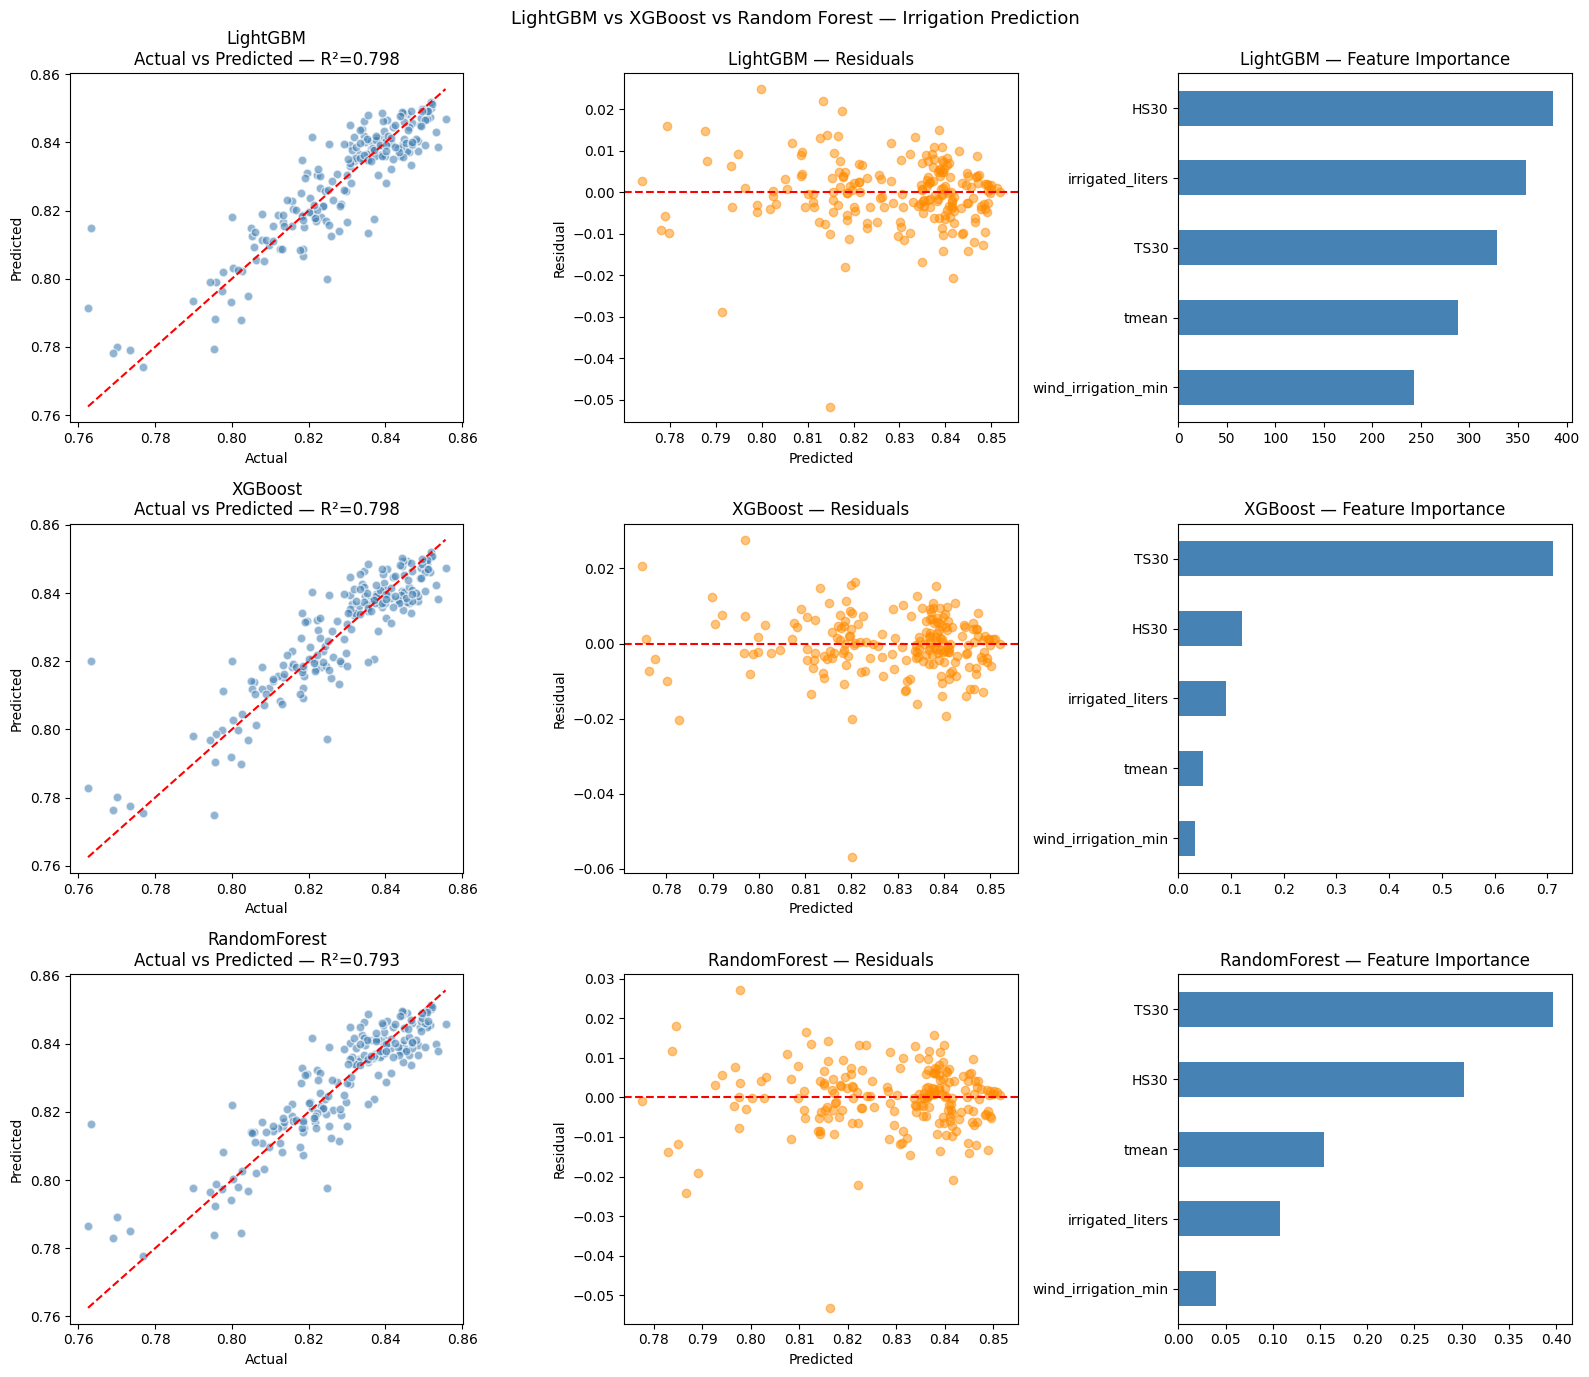

In [ ]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vars_modelo = ['HS30', 'litros_regados',
               'tmedia', 'viento_riego_min', 'TS30']

target = 'HS30_futuro'

X = df_muestras[vars_modelo]
y = df_muestras[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

var_map = {
    'HS30': 'HS30',
    'litros_regados': 'irrigated_liters',
    'tmedia': 'tmean',
    'viento_riego_min': 'wind_irrigation_min',
    'TS30': 'TS30'
}

target_name = "HS30_future"

params = {
    'LightGBM': (
        lgb.LGBMRegressor(random_state=42, verbose=-1),
        {
            'n_estimators': [100, 300, 500],
            'max_depth': [-1, 5, 7],
            'learning_rate': [0.05, 0.1, 0.2],
            'num_leaves': [31, 50],
            'min_child_samples': [10, 20],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
            'reg_alpha': [0, 0.1],
            'reg_lambda': [0, 0.5],
        }
    ),
    'XGBoost': (
        xgb.XGBRegressor(random_state=42, verbosity=0),
        {
            'n_estimators': [100, 300, 500],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.05, 0.1, 0.2],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
            'reg_alpha': [0, 0.1],
            'reg_lambda': [0, 0.5],
            'min_child_weight': [1, 5],
        }
    ),
    'RandomForest': (
        RandomForestRegressor(random_state=42),
        {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 8, 10],
            'min_samples_leaf': [1, 5, 10],
            'max_features': ['sqrt', 0.5, 0.8],
            'max_samples': [0.8, 1.0],
        }
    ),
}

results = {}
models = {}

for name, (model, grid) in params.items():

    print(f"\n{'='*55}")
    print(f"  GridSearch — {name}")
    print(f"{'='*55}")

    search = GridSearchCV(
        estimator=model,
        param_grid=grid,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    search.fit(X_train, y_train)

    y_pred = search.best_estimator_.predict(X_test)
    models[name] = search.best_estimator_

    results[name] = {
        'r2_cv': search.best_score_,
        'r2_test': r2_score(y_test, y_pred),
        'mae': mean_absolute_error(y_test, y_pred),
        'rmse': mean_squared_error(y_test, y_pred) ** 0.5,
        'y_pred': y_pred,
        'params': search.best_params_,
    }

    print(f"\n  ✔ Best hyperparameters — {name}")
    print(f"  R² CV   : {search.best_score_:.4f}")
    print(f"  R² Test : {results[name]['r2_test']:.4f}")
    print(f"  MAE     : {results[name]['mae']:.4f}")
    print(f"  RMSE    : {results[name]['rmse']:.4f}")

print(f"\n{'='*55}")
print("  Final comparison")
print(f"{'='*55}")

print(f"{'Model':<20} {'R² CV':>7} {'R² Test':>8} {'MAE':>8} {'RMSE':>8}")
print("-" * 55)

for name, r in results.items():
    print(f"{name:<20} {r['r2_cv']:>7.4f} {r['r2_test']:>8.4f} "
          f"{r['mae']:>8.4f} {r['rmse']:>8.4f}")

fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for i, (name, r) in enumerate(results.items()):

    # Actual vs Predicted
    axes[i, 0].scatter(y_test, r['y_pred'], alpha=0.6,
                       color='steelblue', edgecolors='white', s=40)

    lims = [min(y_test.min(), r['y_pred'].min()),
            max(y_test.max(), r['y_pred'].max())]

    axes[i, 0].plot(lims, lims, 'r--')
    axes[i, 0].set_title(f"{name}\nActual vs Predicted — R²={r['r2_test']:.3f}")
    axes[i, 0].set_xlabel('Actual')
    axes[i, 0].set_ylabel('Predicted')

    # Residuals
    residuals = y_test.values - r['y_pred']
    axes[i, 1].scatter(r['y_pred'], residuals,
                       color='darkorange', alpha=0.5)

    axes[i, 1].axhline(0, color='red', linestyle='--')
    axes[i, 1].set_title(f'{name} — Residuals')
    axes[i, 1].set_xlabel('Predicted')
    axes[i, 1].set_ylabel('Residual')

    # Feature importance (translated labels)
    model = models[name]

    if name == 'LightGBM':
        imp = pd.Series(model.booster_.feature_importance(),
                        index=vars_modelo)
    else:
        imp = pd.Series(model.feature_importances_, index=vars_modelo)

    imp.index = [var_map[v] for v in imp.index]

    imp.sort_values().plot(kind='barh', ax=axes[i, 2], color='steelblue')
    axes[i, 2].set_title(f'{name} — Feature Importance')

plt.suptitle('LightGBM vs XGBoost vs Random Forest — Irrigation Prediction', fontsize=13)
plt.tight_layout()
plt.show()